In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import ttest_ind, ttest_rel

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
df = pd.read_csv("/content/delhivery_data.csv")

In [ ]:
df.shape

(63060, 24)

In [ ]:
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20-09-2018 4.27,10.435660,14,11,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20-09-2018 4.17,18.936842,24,20,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40,28,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20-09-2018 3.39,36.118028,62,40,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,20-09-2018 3.33,39.386040,68,44,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63060 entries, 0 to 63059
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   data                            63060 non-null  object 
 1   trip_creation_time              63060 non-null  object 
 2   route_schedule_uuid             63060 non-null  object 
 3   route_type                      63060 non-null  object 
 4   trip_uuid                       63060 non-null  object 
 5   source_center                   63060 non-null  object 
 6   source_name                     62927 non-null  object 
 7   destination_center              63060 non-null  object 
 8   destination_name                62964 non-null  object 
 9   od_start_time                   63060 non-null  object 
 10  od_end_time                     63060 non-null  object 
 11  start_scan_to_end_scan          63060 non-null  int64  
 12  is_cutoff                       

In [ ]:
df.describe()

,start_scan_to_end_scan,cutoff_factor,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
count,63060.000000,63060.000000,63060.000000,63060.000000,63060.000000,63060.000000,63060.000000,63059.000000,63059.000000,63059.00000,63059.000000
mean,945.644561,229.184269,230.335283,410.073470,210.773438,280.608542,2.104299,36.083636,18.507747,22.84098,2.216878
std,1018.104546,337.592635,337.806405,585.342066,302.246707,413.223168,1.473226,51.344348,14.340125,17.26405,5.450390
min,20.000000,9.000000,9.000267,9.000000,6.000000,9.072900,0.203125,-211.000000,0.000000,0.00000,-23.444444
25%,164.000000,22.000000,23.440175,52.000000,27.000000,30.123350,1.609004,20.000000,11.000000,12.13270,1.350000
50%,455.000000,66.000000,66.247675,134.000000,65.000000,79.419200,1.857143,29.000000,17.000000,23.54170,1.684211
75%,1546.000000,286.000000,286.514187,507.000000,254.000000,339.747250,2.215385,40.000000,22.000000,27.84365,2.250000
max,4535.000000,1927.000000,1927.447705,4532.000000,1686.000000,2326.199100,77.387097,2464.000000,997.000000,1367.59280,574.250000


In [ ]:
df.isnull().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,0
source_name,133
destination_center,0
destination_name,96
od_start_time,0


In [ ]:
datetime_cols = [
    'trip_creation_time',
    'od_start_time',
    'od_end_time',
    'cutoff_timestamp'
]

# Define the known formats for 'cutoff_timestamp'
# The order matters: try the more specific or less common format first if there's overlap
cutoff_timestamp_formats = [
    '%d-%m-%Y %H.%M',         # For '20-09-2018 4.27'
    '%Y-%m-%d %H:%M:%S.%f'    # For '2018-09-20 04:01:19.505586'
]

for col in datetime_cols:
  if col == 'cutoff_timestamp':
    df[col] = pd.to_datetime(df[col], format=cutoff_timestamp_formats, errors='coerce')
  else:
    # For other datetime columns, let pandas infer if they are consistent, or handle with coerce
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [ ]:
missing_percent = (df.isnull().sum()/len(df))*100
missing_percent

,0
data,0.000000
trip_creation_time,0.000000
route_schedule_uuid,0.000000
route_type,0.000000
trip_uuid,0.000000
source_center,0.000000
source_name,0.210910
destination_center,0.000000
destination_name,0.152236
od_start_time,0.000000


In [ ]:
# Drop rows where source or destination is missing
df.dropna(subset=['source_name', 'destination_name'], inplace=True)

# Fill missing values in route_type
df['route_type'] = df['route_type'].fillna(
    df['route_type'].mode()[0]
)

In [ ]:
trip_segment = df.groupby(
    ['trip_uuid', 'source_center', 'destination_center']
).agg({

    'data':'first',
    'trip_creation_time':'first',
    'route_schedule_uuid':'first',
    'route_type':'first',

    'source_name':'first',
    'destination_name':'first',

    'od_start_time':'first',
    'od_end_time':'last',

    'start_scan_to_end_scan':'first',

    'actual_distance_to_destination':'sum',
    'actual_time':'sum',

    'osrm_time':'sum',
    'osrm_distance':'sum',

    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'segment_osrm_distance':'sum'

}).reset_index()

In [ ]:
trip = trip_segment.groupby('trip_uuid').agg({

    'data':'first',
    'trip_creation_time':'first',
    'route_type':'first',

    'source_name':'first',
    'destination_name':'last',

    'od_start_time':'first',
    'od_end_time':'last',

    'start_scan_to_end_scan':'sum',

    'actual_distance_to_destination':'sum',
    'actual_time':'sum',

    'osrm_time':'sum',
    'osrm_distance':'sum',

    'segment_actual_time':'sum',
    'segment_osrm_time':'sum',
    'segment_osrm_distance':'sum'

}).reset_index()

In [ ]:
trip['source_name'].head()

,source_name
0,Surat_Central_D_12 (Gujarat)
1,Delhi_Lajpat_IP (Delhi)
2,FBD_Balabhgarh_DPC (Haryana)
3,Gulbarga_Nehrugnj_I (Karnataka)
4,Narsinghpur_KndliDPP_D (Madhya Pradesh)


In [ ]:
def split_name_column(name_series):
    # This function ensures that the split always returns two parts
    # even if the delimiter is not found, by padding with NaN.
    def _split_and_pad(s):
        if pd.isna(s) or s == '':
            return [np.nan, np.nan]
        parts = str(s).split('-', 1) # Split at most once
        if len(parts) == 1:
            return [parts[0], np.nan] # Pad with NaN if only one part
        return parts

    return name_series.apply(_split_and_pad).tolist()


trip[['source_city','source_place_code']] = split_name_column(trip['source_name'])
trip[['destination_city','destination_place_code']] = split_name_column(trip['destination_name'])

In [ ]:
trip['trip_year'] = trip['trip_creation_time'].dt.year
trip['trip_month'] = trip['trip_creation_time'].dt.month
trip['trip_day'] = trip['trip_creation_time'].dt.day
trip['trip_hour'] = trip['trip_creation_time'].dt.hour
trip['trip_weekday'] = trip['trip_creation_time'].dt.day_name()

In [ ]:
trip['od_time_diff'] = (
    trip['od_end_time'] - trip['od_start_time']
).dt.total_seconds()/60

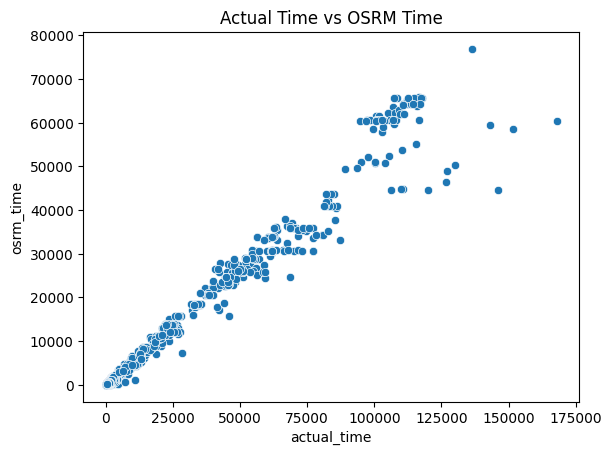

In [ ]:
sns.scatterplot(
    x=trip['actual_time'],
    y=trip['osrm_time']
)

plt.title("Actual Time vs OSRM Time")
plt.show()

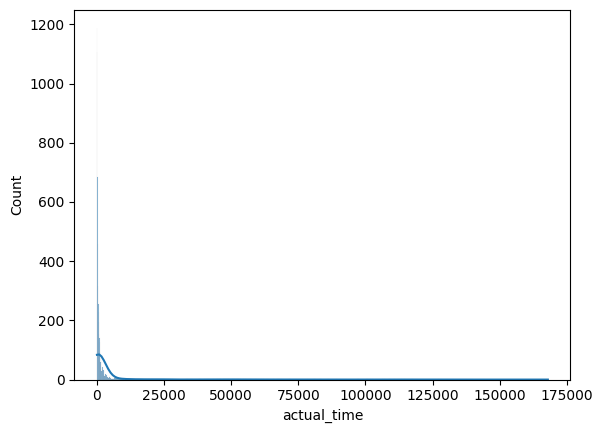

In [ ]:
sns.histplot(trip['actual_time'], kde=True)
plt.show()

In [ ]:
ttest_rel(
    trip['actual_time'],
    trip['osrm_time']
)

TtestResult(statistic=np.float64(21.488007537951507), pvalue=np.float64(5.934714921803515e-99), df=np.int64(6396))

In [ ]:
ttest_rel(
    trip['actual_time'],
    trip['segment_actual_time']
)

TtestResult(statistic=np.float64(20.412057613657144), pvalue=np.float64(9.0094878546703e-90), df=np.int64(6396))

In [ ]:
ttest_rel(
    trip['osrm_distance'],
    trip['segment_osrm_distance']
)

TtestResult(statistic=np.float64(19.982943892736152), pvalue=np.float64(3.1744647603731452e-86), df=np.int64(6396))

In [ ]:
ttest_rel(
    trip['osrm_time'],
    trip['segment_osrm_time']
)

TtestResult(statistic=np.float64(20.161621326145493), pvalue=np.float64(1.0783842676580913e-87), df=np.int64(6396))

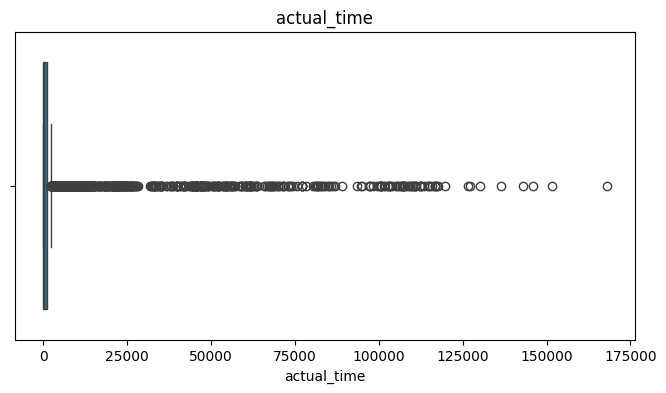

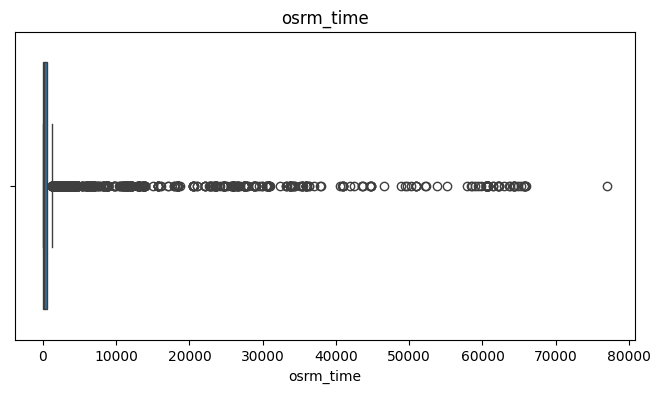

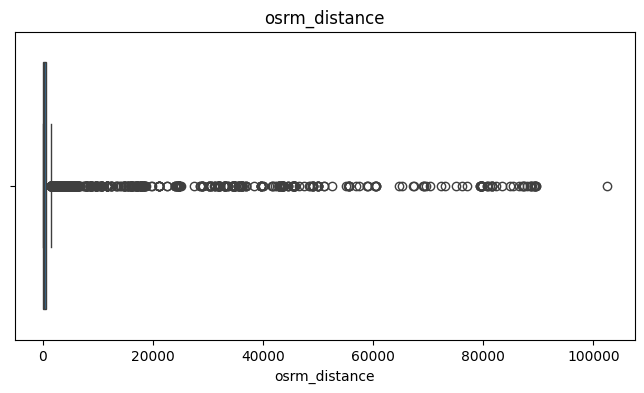

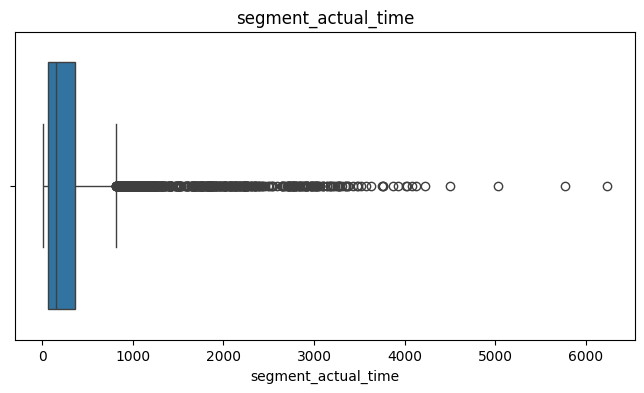

In [ ]:
num_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'segment_actual_time'
]

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=trip[col])
    plt.title(col)
    plt.show()

In [ ]:
def handle_outliers(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(
        df[col] > upper,
        upper,
        np.where(
            df[col] < lower,
            lower,
            df[col]
        )
    )

    return df

In [ ]:
for col in num_cols:
    trip = handle_outliers(trip, col)

In [ ]:
trip = pd.get_dummies(
    trip,
    columns=['route_type'],
    drop_first=True
)

In [ ]:
scaler = StandardScaler()

scale_cols = [
    'actual_time',
    'osrm_time',
    'osrm_distance',
    'segment_actual_time',
    'segment_osrm_time'
]

trip[scale_cols] = scaler.fit_transform(
    trip[scale_cols]
)

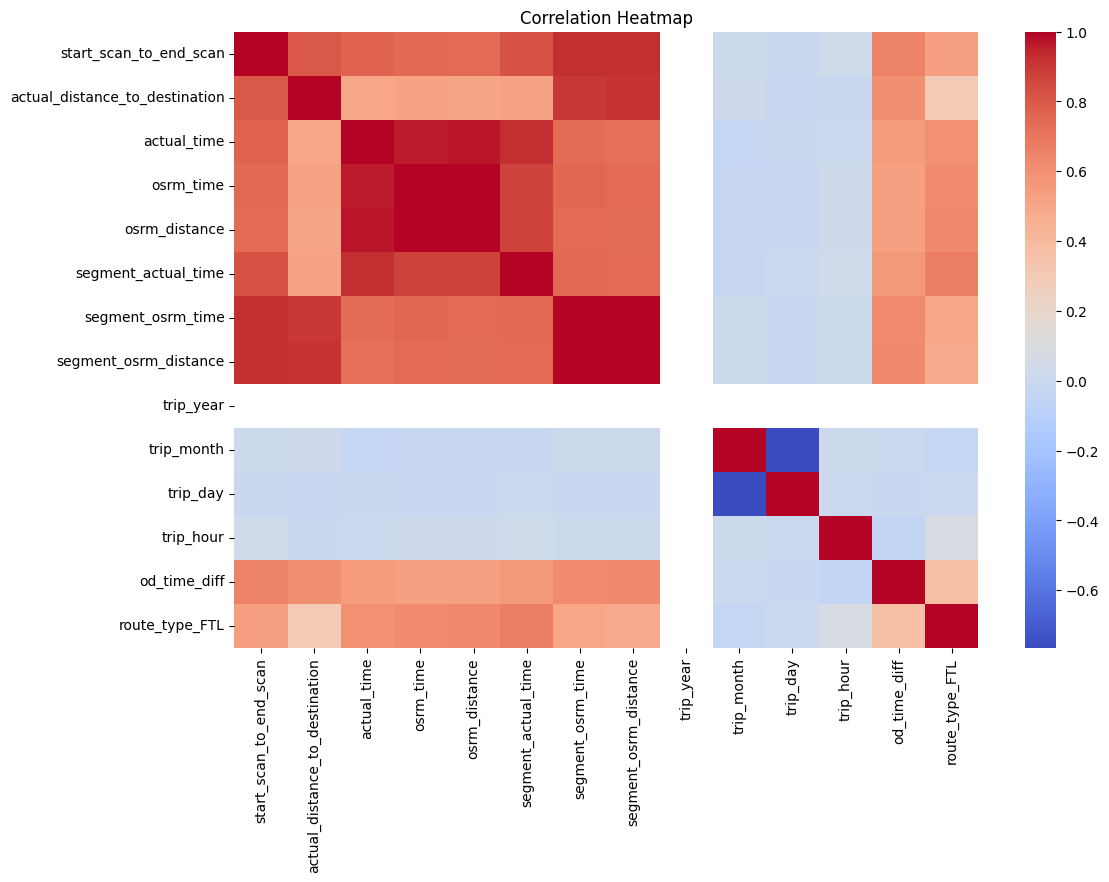

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    trip.corr(numeric_only=True),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()